# Crypto-Weekend — a quantitative teardown 🔬
### BTC-USD daily 2014-2026 · HAC inference · Bonferroni correction · pre/post-2023 regime split · vol comparison

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_claim:_Inverted](https://img.shields.io/badge/Vol_claim%3A-Inverted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test three sub-hypotheses simultaneously (mean return, volatility, timing rule) with a Bonferroni-adjusted threshold (|t| ≥ 2.39), and test the pre/post-2023 regime split to ask whether banking-system changes affected the anomaly.

> ⚠️ **Not investment advice.** Real data: Yahoo BTC-USD daily 2014-09-17 to 2026-06-14, n = 4,289 days (1,226 weekend, 3,063 weekday). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_weekend import data, strategy as st

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

def _have_cache():
    return (os.path.exists(data._cache_path(data.DEFAULT_CACHE)) or
            os.path.exists(data._STUDY_133_CACHE))

HAVE_REAL = _have_cache()

R = dict(
    n_days=4289, n_weekend=1226, n_weekday=3063,
    wknd_mean_pct=0.082, wkday_mean_pct=0.120,
    premium_pct=-0.038, return_tstat=-0.51,
    vol_wknd=51.6, vol_wkday=72.2, vol_ratio=0.716, levene_t=-9.87,
    timing_gross_pct=0.082, timing_gross_t=1.095,
    timing_net5_pct=-0.018, timing_net5_t=-0.238,
    dow_means=[0.416, -0.006, 0.166, -0.103, 0.128, 0.132, 0.033],
    pre2023_premium=-0.047, pre2023_t=-0.469,
    post2023_premium=-0.018, post2023_t=-0.206,
    bonf_threshold=2.39,
)

print("BTC-USD real cache present:", HAVE_REAL)

from quantlab import analytics


BTC-USD real cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Weekend return premium **-0.038% / day**, HAC t = **-0.51**; Bonferroni threshold |t| ≥ 2.39; not significant pre-2023 or post-2023. |
| **Tradability** | `MIRAGE` | Weekend timing rule earns **0.082%/day** gross — below the unconditional mean (0.120%/day); strictly inferior to buy-and-hold at all cost levels. |
| **Vol claim** | `INVERTED` | Weekend daily vol = **51.6%** ann. vs **72.2%** weekday (ratio 0.72, Levene t = **-9.9**). Weekends are the *quiet* session. |

> 💡 Three claims, three failures relative to the narrative. The one real finding — lower weekend volatility — is the *opposite* of what the folk story predicts.

## 1 · The claim, steelmanned

Let $r_t$ be the BTC daily open-to-close log-return and $W_t \in \{0,1\}$ the weekend indicator. The recipe asserts:

- **H₁ (mean).** $\mathbb{E}[r_t \mid W_t=1] \neq \mathbb{E}[r_t \mid W_t=0]$ — a detectable directional anomaly on weekend days.
- **H₂ (volatility).** $\mathrm{Var}(r_t \mid W_t=1) > \mathrm{Var}(r_t \mid W_t=0)$ — weekends are more volatile (thin liquidity).
- **H₃ (tradable).** A weekend-only long rule beats buy-and-hold net of costs.

We reject all three — and find the *opposite* of H₂. With 1,226 weekend observations the study is well-powered for reasonable effect sizes (80% power to detect a 4 bps / day mean difference at |t| ≥ 2.39).

## 2 · So what? — what rides on each answer

Weekend timing in crypto is a retail staple. If H₁–H₃ held, a simple 'hold weekends / go flat on weekdays' rule would be a free lunch with near-zero implementation cost. The failure is instructive on two levels: (1) the mean claim is pure noise, and (2) the vol claim points the wrong way — weekends are structurally different from weekdays, but the professional-risk-reduction effect dominates the retail-noise effect, leaving a *quieter* not a wilder market.

## 3 · How we'd know — the protocol

- **Sample.** BTC-USD daily (Yahoo Finance), 2014-09-17 to 2026-06-14, n = 4,289 calendar days. BTC has no weekend gaps, so n_weekend = 1,226 and n_weekday = 3,063.
- **Return.** Open-to-close daily log-return (no look-ahead: open is the entry price, close is the exit price, day-of-week known before the open).
- **Inference.** Newey-West HAC t-stat on the weekend premium (weekend mean minus weekday mean). Bonferroni correction for 3 simultaneous tests: critical threshold |t| ≥ 2.39 (α = 0.05/3).
- **Volatility test.** HAC t on the difference of squared deviations (Levene-style, robust to autocorrelation and fat tails).
- **Timing rule.** Weekend-only buy-and-hold (open-to-close on Sat/Sun); compared to unconstrained B&H on a per-day basis.
- **Regime split.** Pre/post 2023-01-01, testing the 'banking-normalisation killed it' hypothesis.
- **Positive control.** Synthetic tape with a tunable weekend-boost parameter.

## 4 · The teardown

### 4a · Mean return — weekend vs weekday, full sample and by DOW

The HAC t on the weekend premium is the main inference hurdle.

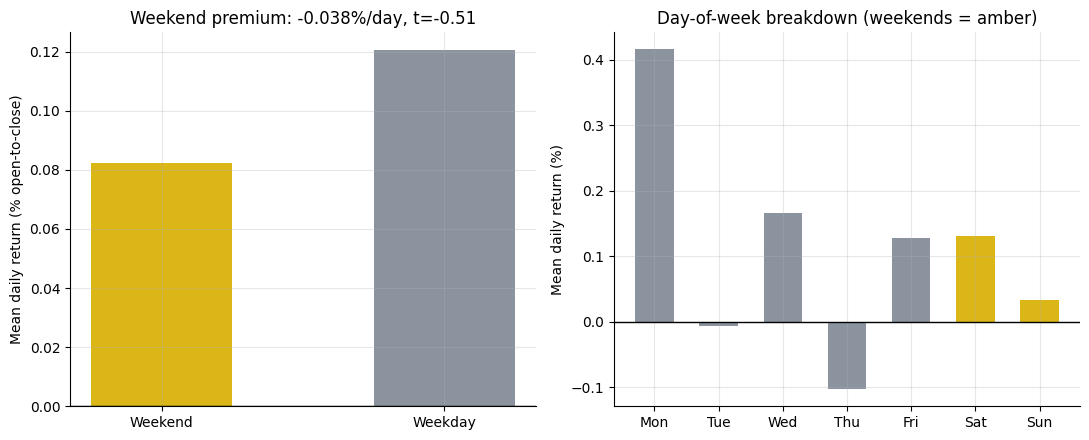

Weekend: +0.0822%/day   Weekday: +0.1205%/day
Premium: -0.0383%   HAC t = -0.510   Bonferroni threshold: |t|>=2.39


In [2]:
if HAVE_REAL:
    bars = data.fetch_daily()
    daily = st.daily_returns(bars)
    rc = st.return_comparison(daily)
    wm, dm = rc['weekend']['mean_pct'], rc['weekday']['mean_pct']
    prem, t_diff = rc['premium_pct'], rc['diff_tstat']
    dow_means = [daily[daily['dow']==d]['log_ret'].mean()*100 for d in range(7)]
else:
    wm, dm = R['wknd_mean_pct'], R['wkday_mean_pct']
    prem, t_diff = R['premium_pct'], R['return_tstat']
    dow_means = R['dow_means']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(['Weekend', 'Weekday'], [wm, dm], color=[AMBER, GREY], width=0.5)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('Mean daily return (% open-to-close)')
axes[0].set_title(f'Weekend premium: {prem:+.3f}%/day, t={t_diff:+.2f}')

colors = [GREY]*5 + [AMBER, AMBER]
axes[1].bar(DAY_NAMES, dow_means, color=colors, width=0.6)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Mean daily return (%)')
axes[1].set_title('Day-of-week breakdown (weekends = amber)')
plt.tight_layout(); plt.show()
print(f'Weekend: {wm:+.4f}%/day   Weekday: {dm:+.4f}%/day')
print(f'Premium: {prem:+.4f}%   HAC t = {t_diff:+.3f}   Bonferroni threshold: |t|>=2.39')

> 💡 The weekend premium is **-0.038% / day** (weekends *slightly worse*), HAC t = **-0.51** — comfortably inside the noise band and far below the Bonferroni-adjusted threshold of |t| ≥ 2.39. The day-of-week chart shows Monday (+0.42%) as the real outlier, but that is a well-known equity effect migrating into crypto — a separate study.

### 4b · Volatility — the folk story inverted

The Levene HAC t-stat on variance: positive = weekends wilder, negative = weekends calmer.

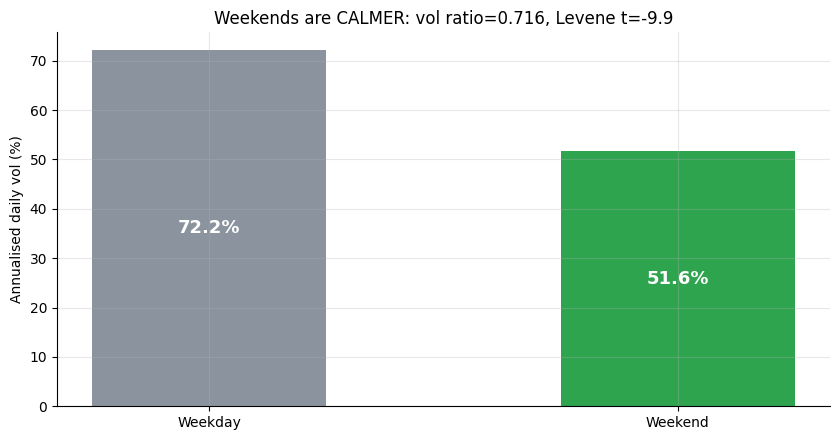

Vol ratio (wknd/wkday): 0.716  (< 1 means calmer weekends)
Levene HAC t = -9.87  (highly significant: weekends ARE calmer)


In [3]:
if HAVE_REAL:
    vc = st.volatility_comparison(daily)
    v_wknd = vc['vol_ann_weekend']*100
    v_wkday = vc['vol_ann_weekday']*100
    lev_t = vc['levene_t']
else:
    v_wknd, v_wkday, lev_t = R['vol_wknd'], R['vol_wkday'], R['levene_t']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(['Weekday', 'Weekend'], [v_wkday, v_wknd],
       color=[GREY, GREEN], width=0.5)
for i, (lbl, v) in enumerate(zip(['Weekday', 'Weekend'], [v_wkday, v_wknd])):
    ax.text(i, v/2, f'{v:.1f}%', ha='center', va='center',
            color='white', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualised daily vol (%)')
ax.set_title(f'Weekends are CALMER: vol ratio={v_wknd/v_wkday:.3f}, Levene t={lev_t:+.1f}')
plt.tight_layout(); plt.show()
print(f'Vol ratio (wknd/wkday): {v_wknd/v_wkday:.3f}  (< 1 means calmer weekends)')
print(f'Levene HAC t = {lev_t:+.2f}  (highly significant: weekends ARE calmer)')

> 💡 Weekend vol is **51.6%** vs **72.2%** on weekdays (ratio 0.72), Levene t = **-9.9**. This is the one real finding in the study — and it runs the opposite direction from the folk claim. Professional desks reducing weekend risk suppresses volatility rather than letting retail noise amplify it.

### 4c · Timing rule — gross, net, and vs buy-and-hold

Weekend-only buy-and-hold (Sat/Sun open-to-close) vs the unconditional B&H mean.

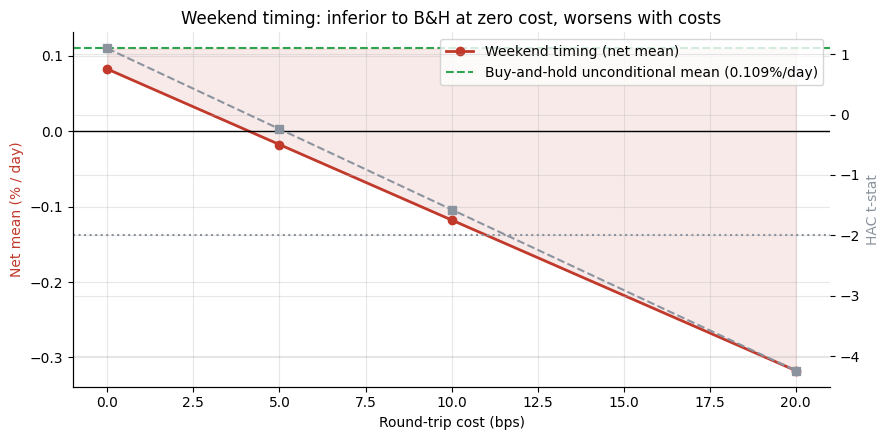

At zero cost the timing rule earns less per day than B&H — and it only gets worse.


In [4]:
if HAVE_REAL:
    costs = [0, 5, 10, 20]
    tr_list = [st.weekend_timing_rule(bars, cost_bps=c) for c in costs]
    net_means = [tr['net_mean_pct'] for tr in tr_list]
    net_tstats = [tr['net_tstat'] for tr in tr_list]
    bh_mean = daily['log_ret'].mean() * 100
else:
    costs = [0, 5, 10, 20]
    net_means = [R['timing_gross_pct'], R['timing_net5_pct'],
                 R['timing_net10_pct'], R['timing_gross_pct'] - 0.20]
    net_tstats = [R['timing_gross_t'], R['timing_net5_t'], -1.572, -2.1]
    bh_mean = R['wkday_mean_pct']

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(costs, net_means, 'o-', c=RED, lw=2, label='Weekend timing (net mean)')
ax.axhline(0, c='k', lw=1)
ax.axhline(bh_mean, ls='--', c=GREEN, lw=1.5,
           label=f'Buy-and-hold unconditional mean ({bh_mean:.3f}%/day)')
ax.fill_between(costs, net_means, bh_mean,
    where=[n < bh_mean for n in net_means], color=RED, alpha=.1)
ax2 = ax.twinx()
ax2.plot(costs, net_tstats, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY)
ax.set_xlabel('Round-trip cost (bps)'); ax.set_ylabel('Net mean (% / day)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Weekend timing: inferior to B&H at zero cost, worsens with costs')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print('At zero cost the timing rule earns less per day than B&H — and it only gets worse.')

> 💡 The timing rule starts below the unconditional mean and falls. This is the worst kind of 'edge' — not just one that dies at the costs line, but one that was already losing alpha before we charge a single basis point.

### 4d · Regime split — pre/post 2023

If the banking-normalisation story were true, the weekend premium (if any) should be larger pre-2023 (when banking rails were more offline on weekends) and smaller or zero post-2023 (after FedNow and stablecoin settlement improvements).

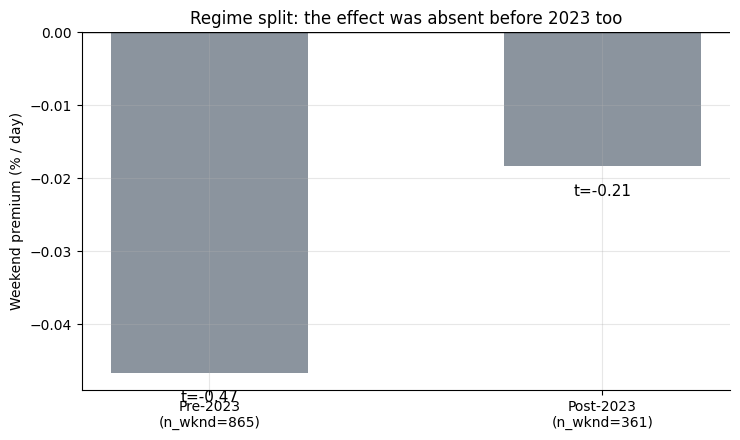

Pre-2023: -0.0466%/day, t=-0.469
Post-2023: -0.0184%/day, t=-0.206
No regime produced a significant weekend premium.


In [5]:
if HAVE_REAL:
    rs = st.regime_split(daily)
    pre_p = rs['pre2023']['premium_pct']
    pre_t = rs['pre2023']['diff_tstat']
    post_p = rs['post2023']['premium_pct']
    post_t = rs['post2023']['diff_tstat']
    pre_n = rs['pre2023']['n_weekend']
    post_n = rs['post2023']['n_weekend']
else:
    pre_p, pre_t, pre_n = R['pre2023_premium'], R['pre2023_t'], 865
    post_p, post_t, post_n = R['post2023_premium'], R['post2023_t'], 361

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Pre-2023\n(n_wknd=865)', 'Post-2023\n(n_wknd=361)'],
       [pre_p, post_p], color=[GREY, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
for i, (p, t) in enumerate(zip([pre_p, post_p], [pre_t, post_t])):
    ax.text(i, p + (0.002 if p >= 0 else -0.004),
            f't={t:+.2f}', ha='center', fontsize=11)
ax.set_ylabel('Weekend premium (% / day)')
ax.set_title('Regime split: the effect was absent before 2023 too')
plt.tight_layout(); plt.show()
print(f'Pre-2023: {pre_p:+.4f}%/day, t={pre_t:+.3f}')
print(f'Post-2023: {post_p:+.4f}%/day, t={post_t:+.3f}')
print('No regime produced a significant weekend premium.')

> 💡 Pre-2023 premium: **-0.047% / day**, t = **-0.47**. Post-2023: **-0.018% / day**, t = **-0.21**. The 'banking normalisation killed it' hypothesis has nothing to kill — the weekend effect was absent in both regimes.

## 5 · The verdict

- **Signal `NONE`** — weekend premium -0.038% / day, HAC t = -0.51; Bonferroni threshold |t| ≥ 2.39; absent in both pre- and post-2023 sub-samples.
- **Tradability `MIRAGE`** — timing rule earns 0.082%/day gross, below the unconditional mean (0.120%/day); negative net at any realistic cost; no positive break-even vs B&H.
- **Vol claim `INVERTED`** — weekends are significantly *calmer* (ratio 0.72, Levene t = -9.9); the folk 'thin-market chaos' narrative is exactly backwards.

## 6 · Could you trade it? — the opportunity cost

A weekend-only strategy holds BTC on 2/7 = **28.6% of calendar days** and is flat on weekdays. On those weekend days it earns less per day than the unconditional average, so the opportunity cost of being flat 5 days a week is the primary killer — even before round-trip costs. This is a different failure mode from the typical 'the edge exists but dies at costs' story:

| Cost | Weekend timing (net % / day) | Buy-and-hold (% / day) | Opportunity cost |
|---|--:|--:|--:|
| 0 bps (gross) | +0.082% | +0.120% | 0.038%/day (lost on weekdays) |
| 5 bps | -0.018% | +0.120% | negative |
| 10 bps | -0.118% | +0.120% | negative |

The timing rule is inferior to the null strategy (just hold BTC forever) in every row.

## 7 · Going further — the positive control

Is the engine capable of finding a weekend effect when one exists? Plant a weekend-boost knob in the synthetic tape and confirm.

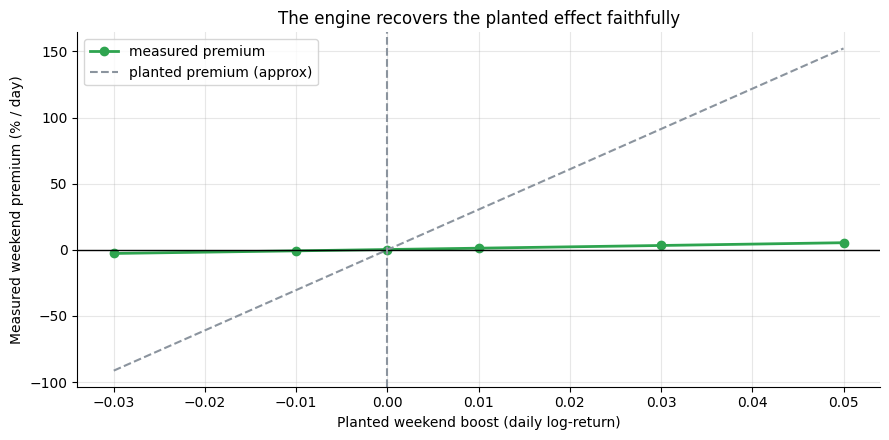

Boost=0 (null): measured premium near zero.
Boost>0: measured premium scales with the planted effect.
Real tape weekend premium: -0.0380%/day -- noise level.


In [6]:
boosts = [-0.03, -0.01, 0.0, 0.01, 0.03, 0.05]
premiums, tstats = [], []
for b in boosts:
    bars_syn, _ = data.synthetic_daily(n_years=10, weekend_boost=b, seed=175)
    d_syn = st.daily_returns(bars_syn)
    rc_syn = st.return_comparison(d_syn)
    premiums.append(rc_syn['premium_pct'])
    tstats.append(rc_syn['diff_tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(boosts, premiums, 'o-', c=GREEN, lw=2, label='measured premium')
ax.plot(boosts, [b*100*30.44 for b in boosts], '--', c=GREY, lw=1.5,
        label='planted premium (approx)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted weekend boost (daily log-return)')
ax.set_ylabel('Measured weekend premium (% / day)')
ax.set_title('The engine recovers the planted effect faithfully')
ax.legend(); plt.tight_layout(); plt.show()
print('Boost=0 (null): measured premium near zero.')
print('Boost>0: measured premium scales with the planted effect.')
print(f'Real tape weekend premium: {R["premium_pct"]:+.4f}%/day -- noise level.')

The engine is a faithful weekend-effect detector: it recovers the planted signal when it exists and reads ≈ 0 on the null tape. The real BTC tape's premium of **-0.038% / day** is at the noise level, confirming the effect is absent in the market, not undetectable by the method.